#**Packages**

In [15]:
import numpy as np
import matplotlib.pyplot as plt

#**Mesh Generation**

In [16]:
def create_mesh(a, b, n, flag):
    # creates 3 different types of meshes (uniform, Chebyshev 1, Chebyshev 2)

    # Parameters:
        # a: lower bound of the interval
        # b: upper bound of the interval
        # n: number of points
        # flag: flag indicating which kind of mesh to create (1 for uniform, 2 for Chebyshev 1st kind, 3 for Chebyshev 2nd kind)

    # Returns:
        # x_mesh: mesh of points of the desired type

    x_mesh = np.zeros(n+1)   # initializes storage

    if flag == 1: # creates a uniform mesh
        x_mesh = np.linspace(a, b, n+1)

    elif flag == 2:   # creates Chebyshev points of the 1st kind
        for i in range(n+1):
            x_mesh[i] = 0.5*(b-a) * np.cos(((2*i + 1) * np.pi) / (2 * n + 2)) + 0.5*(b+a)

    elif flag == 3:   # creates Chebyshev points of the 2nd kind
        for i in range(n+1):
            x_mesh[i] = 0.5*(b-a) * np.cos((i * np.pi)/ n) + 0.5*(b+a)

    return x_mesh



#**Barycentric 1**

In [17]:
def bary_1_gammas(x_mesh, f, dtype=np.float32, **kwargs):
    # Computes the gamma coefficients in the Barycentric 1 formula
    # Computes the function values at the mesh points

    n = len(x_mesh) - 1  # The mesh has n+1 points
    x_mesh = np.array(x_mesh, dtype=dtype)

    gamma_weights = np.zeros(n + 1, dtype=dtype)   # Initializes storage

    # Compute gamma weights
    for i in range(n + 1):
        omega_prime = dtype(1)
        for j in range(n + 1):  # Computes the omega primes (skips j=i case)
            if j != i:
                omega_prime *= dtype(x_mesh[i] - x_mesh[j])
        gamma_weights[i] = dtype(1) / omega_prime   # Computes inverse for gammas

    # Compute function values
    function_values = np.array(f(x_mesh, **kwargs), dtype=dtype)  # Pass entire x_mesh at once

    return gamma_weights, function_values


def bary_1_interpolation(x_mesh, y_mesh, x_points, gamma_weights, dtype=np.float32):
    # Evaluates Barycentric Form 1 interpolation

    x_mesh = np.array(x_mesh, dtype=dtype)  # Ensures everything is in correct precision
    y_mesh = np.array(y_mesh, dtype=dtype)
    x_points = np.array(x_points, dtype=dtype)
    gamma_weights = np.array(gamma_weights, dtype=dtype)

    n = len(x_mesh) - 1  # Degree n polynomial for n+1 points
    eval_len = len(x_points)
    interp_eval = np.zeros(eval_len, dtype=dtype)  # Initializing result array

    cond_xn1 = np.zeros(eval_len)
    cond_xny_numerator = np.zeros(eval_len)

    for j in range(eval_len):  # Looping over points to be interpolated
        numerically_close = np.isclose(x_points[j], x_mesh, atol=np.finfo(dtype).eps).any()

        if numerically_close:  # If an interpolated point is close to a mesh point, use the exact y value
            interp_eval[j] = y_mesh[np.argmin(np.abs(x_points[j] - x_mesh))]
            continue

        omega = dtype(1)
        for i in range(n + 1):
            omega *= dtype(x_points[j] - x_mesh[i])  # Computing omega_{n+1}(x)

        term = dtype(0)
        for i in range(n + 1):  # Computing the weighted sum using gamma_weights
            term += dtype((y_mesh[i] * gamma_weights[i]) / dtype(x_points[j] - x_mesh[i]))

        interp_eval[j] = dtype(omega * term)  # Computing p_n(x)

        # Conditioning for Barycentric 1
        sum_xn1 = 0
        sum_xny = 0
        for i in range(n+1):
            l_i = (gamma_weights[i] * omega) / (x_points[j] - x_mesh[i])
            sum_xn1 += np.abs(l_i)
            l_i_y = l_i * y_mesh[i]
            sum_xny += np.abs(l_i_y)
        cond_xn1[j] = sum_xn1
        cond_xny_numerator[j] = sum_xny

    return interp_eval, cond_xn1, cond_xny_numerator



#**Barycentric 2**

In [18]:
def bary_2_betas(x_mesh, mesh_type, n, f, dtype=np.float32, **kwargs):
    # Computes the beta coefficients in the Barycentric 2 formula
    # Computes the function values at the mesh points

    beta_weights = np.zeros(n + 1, dtype=dtype)   # Initializes storage
    function_values = np.zeros(n + 1, dtype=dtype)

    if mesh_type == 1:  # Uniform mesh
        beta_weights[0] = dtype(1)
        for i in range(n):
            beta_weights[i + 1] = dtype(-1) * beta_weights[i] * dtype((n - i) / (i + 1))

    elif mesh_type == 2:  # Chebyshev 1st kind
        for i in range(n + 1):
            beta_weights[i] = dtype((-1) ** i) * dtype(np.sin(dtype(((2 * i + 1) * np.pi) / (2 * n + 2))))

    elif mesh_type == 3:  # Chebyshev 2nd kind
        for i in range(n + 1):
            if i == 0 or i == n:
                beta_weights[i] = dtype((-1) ** i) * dtype(0.5)
            else:
                beta_weights[i] = dtype((-1) ** i)


    function_values = np.array(f(x_mesh, **kwargs), dtype=dtype)  # Pass entire x_mesh at once

    return beta_weights, function_values


def bary_2_interpolation(x_mesh, y_mesh, x_points, beta_weights, dtype=np.float32):
    # Evaluates Barycentric Form 2 interpolation

    x_mesh = np.array(x_mesh, dtype=dtype)  # Ensures correct precision
    y_mesh = np.array(y_mesh, dtype=dtype)
    x_points = np.array(x_points, dtype=dtype)
    beta_weights = np.array(beta_weights, dtype=dtype)

    n = len(x_mesh) - 1  # Degree n polynomial for n+1 points
    eval_len = len(x_points)
    interp_eval = np.zeros(eval_len, dtype=dtype)  # Initializing result array

    cond_xn1 = np.zeros(eval_len)
    cond_xny = np.zeros(eval_len)

    for j in range(eval_len):  # Looping over points to be interpolated
        numerically_close = np.isclose(x_points[j], x_mesh, atol=np.finfo(dtype).eps).any()

        if numerically_close:  # If an interpolated point is close to a mesh point, use the exact y value
            interp_eval[j] = y_mesh[np.argmin(np.abs(x_points[j] - x_mesh))]
            continue

        numerator = dtype(0)
        denominator = dtype(0)
        for i in range(n + 1):  # Compute the Barycentric 2 formula
            term = dtype(1) / dtype(x_points[j] - x_mesh[i])
            numerator += dtype(y_mesh[i] * beta_weights[i] * term)
            denominator += dtype(beta_weights[i] * term)

        interp_eval[j] = dtype(numerator / denominator)  # Compute p_n(x)

        xn1_numer_sum = 0
        xn1_denom_sum = 0
        xny_numer_sum = 0
        xny_denom_sum = 0
        for i in range(n+1):
            frac = beta_weights[i] / (x_points[j] - x_mesh[i])
            frac_y = frac * y_mesh[i]
            xn1_numer_sum += np.abs(frac)
            xn1_denom_sum += frac
            xn1_denom_sum = np.abs(xn1_denom_sum)
            xny_numer_sum += np.abs(frac_y)
            xny_denom_sum += frac_y
            xny_denom_sum = np.abs(xny_denom_sum)
        cond_xn1[j] = xn1_numer_sum / xn1_denom_sum
        cond_xny[j] = xny_numer_sum / xny_denom_sum

    return interp_eval, cond_xn1, cond_xny



#**Divided Differences & Horner's Rule Interpolation**

In [19]:
def divided_differences(x_mesh, f, dtype=np.float32, **kwargs):
    # Computes function values at given mesh points
    # Computes divided differences and stores them in a 1D array (O(n) space complexity)

    # Parameters:
        # x_mesh: mesh points
        # f: function to be interpolated
        # dtype: floating-point precision (np.float32 or np.float64)

    # Returns:
        # div_diff_list: 1D array of divided differences
        # function_values: the function values to be used in the interpolation

    n = len(x_mesh)

    function_values = np.zeros(n, dtype=dtype)  # Initialize in specified precision
    function_values = np.array(f(x_mesh, **kwargs), dtype=dtype)  # Pass entire x_mesh at once

    coeffs = np.copy(function_values).astype(dtype)  # Initialize coefficients array

    for i in range(1, n):  # Compute divided differences iteratively
        for j in range(n-1, i-1, -1):
            coeffs[j] = dtype((coeffs[j] - coeffs[j-1]) / (x_mesh[j] - x_mesh[j-i]))

    return coeffs, function_values


def horner_interpolation(x_mesh, f, x_vals, dtype=np.float32, **kwargs):
    # Evaluates the Newton interpolation polynomial at given points using Horner's method.

    # Parameters:
        # x_mesh: mesh points
        # f: the function to be used in the interpolation
        # x_vals: x points to be interpolated
        # dtype: floating-point precision (np.float32 or np.float64)

    # Returns:
        # interp_eval: the interpolation polynomial evaluated at the x_vals

    n = len(x_mesh)  # Number of interpolation points
    coeffs, _ = divided_differences(x_mesh, f, dtype=dtype, **kwargs)  # Compute divided differences with correct precision

    x_mesh = np.array(x_mesh, dtype=dtype)  # Convert mesh to correct precision
    x_vals = np.array(x_vals, dtype=dtype)
    interp_eval = np.zeros(len(x_vals), dtype=dtype)  # Initialize output array

    for k, xk in enumerate(x_vals):  # Evaluate Newton polynomial at each x_point using Horner's rule
        s = dtype(coeffs[-1])  # Start with the last coefficient
        for i in range(n - 2, -1, -1):  # Iterate backwards for Horner's rule
            s = dtype(s * (xk - x_mesh[i]) + coeffs[i])  # Ensure computations stay in correct precision
        interp_eval[k] = s

    return interp_eval  # Return the evaluated interpolation values




#**Ordering Mesh Points**

In [20]:
def mesh_order(xi, flag):
    # Orders a set of distinct mesh points in increasing, decreasing, or Leja order.

    # Parameters:
        # xi (list): Unordered mesh points.
        # flag (int): flag to indicate which type of ordering to use (1 for increasing, 2 for decreasing, 3 for Leja)

    # Returns:
        # ordered_xi (list): Ordered mesh points.

    n = len(xi)
    ordered_xi = xi.copy()

    if flag == 1:
        # Sort in increasing order (using a bubble sort algorithm)
        for i in range(n):
            for j in range(0, n-i-1):
                if ordered_xi[j] > ordered_xi[j+1]:
                    ordered_xi[j], ordered_xi[j+1] = ordered_xi[j+1], ordered_xi[j]

    elif flag == 2:
        # Sort in decreasing order (using a bubble sort algorithm)
        for i in range(n):
            for j in range(0, n-i-1):
                if ordered_xi[j] < ordered_xi[j+1]:
                    ordered_xi[j], ordered_xi[j+1] = ordered_xi[j+1], ordered_xi[j]

    elif flag == 3:
        ordered_xi = np.array(ordered_xi)

        # Find the index of the mesh point with the largest absolute value
        # Swap largest absolute value to first position
        i = np.argmax(np.abs(ordered_xi))
        ordered_xi[0], ordered_xi[i] = ordered_xi[i], ordered_xi[0]

        for i in range(1, n):
            # Initialize the product array that stores the cumulative product of differences for each candidate point
            p = np.ones(n)

            # Iteratively select Leja points
            for j in range(i, n):
                for k in range(i):  # Only examine already selected points
                    p[j] *= abs(ordered_xi[j] - ordered_xi[k])  # Compute product of differences for remaining points

                # Find the index of the next point that maximizes the absolute product
                max_index = np.argmax(np.abs(p[i:n])) + i   # Adding i is necessary to adjust to the original array location
                ordered_xi[i], ordered_xi[max_index] = ordered_xi[max_index], ordered_xi[i]  # Swap to enforce Leja ordering

    return ordered_xi




#**Error Statistics**

In [21]:
def compute_max_norm(x,y):
    if len(x) != len(y):
        raise ValueError("Input arrays must have the same length")
    else:
        return np.max(np.abs(x-y))

def relative_error(pn, pn_hat):
    # Calculate the modified relative error (data lost in single precision)
    #epsilon = 1e-8  # Small threshold to prevent division by near-zero values
    with np.errstate(divide='ignore', invalid='ignore'):
        #rel_error = np.abs(pn - pn_hat) / np.maximum(np.abs(pn), epsilon)
        rel_error = np.abs(pn - pn_hat) / np.abs(pn)
        #rel_error[np.isinf(rel_error)] = 0  # Replace infinite values with 0
        #rel_error = np.nan_to_num(rel_error)  # Replace NaN values with 0
    return np.abs(rel_error)



#**Define Functions**

In [22]:
def f1(x):
    return (x-2)**9

def f2(x,d):
    result = 1
    for i in range(1, d+1):
        result *= (x-i)
    return result

def f3(x_mesh, x_points):
    result = np.zeros(len(x_points))
    for j in range(len(x_points)):
        if np.isclose(x_points[j], x_mesh, atol=np.finfo(np.float64).eps).any() and x_points[j] != x_mesh[-1]:
            result[j] = 0
        elif x_points[j] == x_mesh[-1]:
            result[j] = 1
        else:
            prod = 1
            for i in range(len(x_mesh)-1):
                prod *= (x_points[j] - x_mesh[i]) / (x_mesh[-1] - x_mesh[i])
            result[j] = prod
    return result

def f4(x):
    return 1 / (1 + 25 * x**2)




#**Task 1**

Maximum Pointwise Error (Barycentric 1): 0.0001488357446532973
Maximum Pointwise Error (Barycentric 2): 1.654063193257116e-05
Maximum Pointwise Error (Newton)): 4.623930786712416e-05


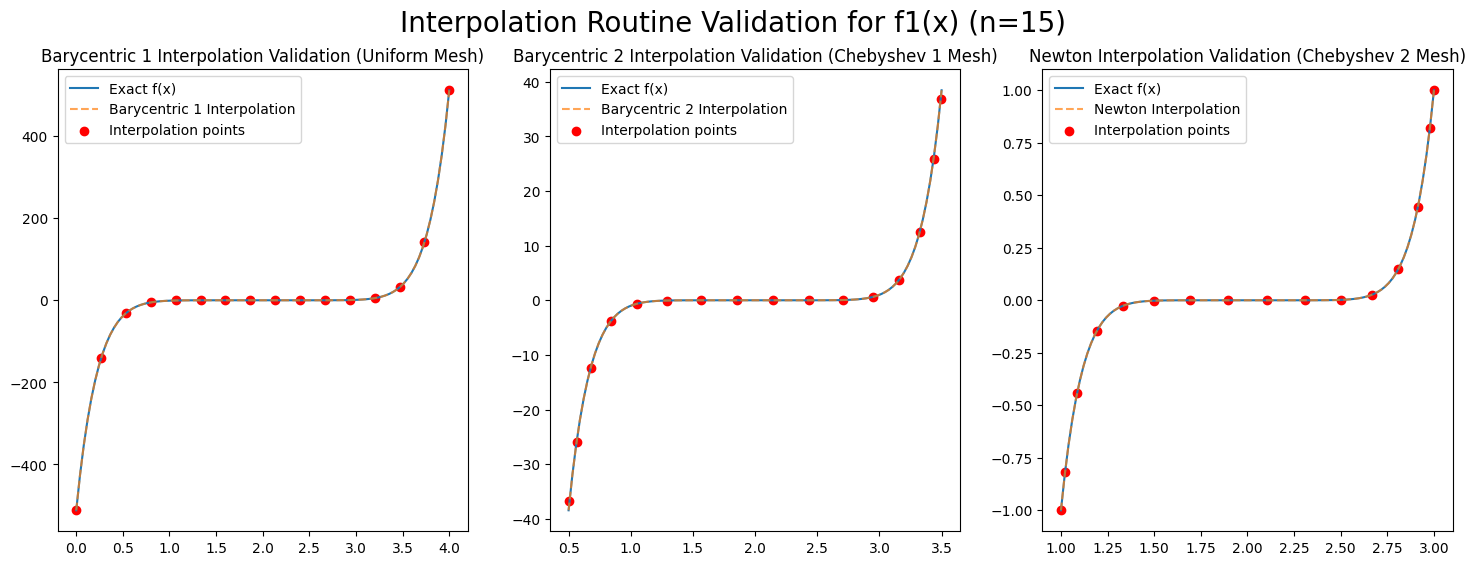

<Figure size 640x480 with 0 Axes>

In [23]:
# Empirically validating the interpolation routine for Barycentric 1

# Interpolation mesh
x_mesh = create_mesh(0, 4, 15, 1)
y_mesh = f1(x_mesh)

# Compute barycentric 1 weights
gamma_weights, function_values = bary_1_gammas(x_mesh, f1)

# Evaluate interpolant
x_points = np.linspace(0, 4, 100)
y_exact = f1(x_points)
y_interp, cond_xn1, cond_xny_numerator = bary_1_interpolation(x_mesh, y_mesh, x_points, gamma_weights)

# Plot results

plt.figure(figsize=(18, 6))
plt.suptitle("Interpolation Routine Validation for f1(x) (n=15)", ha='center', fontsize=20)

plt.subplot(1, 3, 1)
plt.plot(x_points, y_exact, label="Exact f(x)")
plt.plot(x_points, y_interp, '--', label="Barycentric 1 Interpolation", alpha=0.7)
plt.scatter(x_mesh, y_mesh, color="red", label="Interpolation points")
plt.legend()
plt.title("Barycentric 1 Interpolation Validation (Uniform Mesh)")

# Compute maximum pointwise error
max_error_b1 = compute_max_norm(y_interp, y_exact)
print("Maximum Pointwise Error (Barycentric 1):", max_error_b1)


# Empirically validating the interpolation routine for Barycentric 2

# Interpolation mesh
x_mesh = create_mesh(0.5, 3.5, 15, 2)
y_mesh = f1(x_mesh)

# Compute barycentric weights
beta_weights, function_values = bary_2_betas(x_mesh, 2, 15, f1)

# Evaluate interpolant
x_points = np.linspace(0.5, 3.5, 100)
y_exact = f1(x_points)
y_interp, cond_xn1, cond_xny = bary_2_interpolation(x_mesh, y_mesh, x_points, beta_weights)

# Plot results
plt.subplot(1, 3, 2)
plt.plot(x_points, y_exact, label="Exact f(x)")
plt.plot(x_points, y_interp, '--', label="Barycentric 2 Interpolation", alpha=0.7)
plt.scatter(x_mesh, y_mesh, color="red", label="Interpolation points")
plt.legend()
plt.title("Barycentric 2 Interpolation Validation (Chebyshev 1 Mesh)")

# Compute maximum pointwise error
max_error_b2 = compute_max_norm(y_interp, y_exact)
print("Maximum Pointwise Error (Barycentric 2):", max_error_b2)


# Empirically validating the interpolation routine for Newton

# Interpolation mesh
x_mesh = create_mesh(1, 3, 15, 3)
y_mesh = f1(x_mesh)

# Evaluate interpolant
x_points = np.linspace(1, 3, 100)
y_exact = f1(x_points)
y_interp = horner_interpolation(x_mesh, f1, x_points)

# Plot results
plt.subplot(1, 3, 3)
plt.plot(x_points, y_exact, label="Exact f(x)")
plt.plot(x_points, y_interp, '--', label="Newton Interpolation", alpha=0.7)
plt.scatter(x_mesh, y_mesh, color="red", label="Interpolation points")
plt.legend()
plt.title("Newton Interpolation Validation (Chebyshev 2 Mesh)")

# Compute maximum pointwise error
max_error_n = compute_max_norm(y_interp, y_exact)
print("Maximum Pointwise Error (Newton)):", max_error_n)

plt.show()
plt.tight_layout(rect=[0, 0, 1, 0.95])



#**Tasks 2,3,4 Subtask 1**

Maximum Pointwise Error (Bary 1 Uniform): 38.5832890230231
Maximum Pointwise Error (Bary 1 Chebyshev 1): 0.10063051315955818
Maximum Pointwise Error (Bary 1 Chebyshev 2): 0.10587416042108089
Maximum Pointwise Error (Bary 2 Uniform): 1037.864539023023
Maximum Pointwise Error (Bary 2 Chebyshev 1): 0.0625
Maximum Pointwise Error (Bary 2 Chebyshev 2): 0.04324408029788174
Maximum Pointwise Error (Newton Increasing Uniform): 10.166710976976901
Maximum Pointwise Error (Newton Increasing Chebyshev 1): 23.573313667074675
Maximum Pointwise Error (Newton Increasing Chebyshev 2): 115.35710995809728
Maximum Pointwise Error (Newton Decreasing Uniform): 10.135460976976901
Maximum Pointwise Error (Newton Decreasing Chebyshev 1): 0.06938051315955818
Maximum Pointwise Error (Newton Decreasing Chebyshev 2): 0.0720028257346712
Maximum Pointwise Error (Newton Leja Uniform): 1865.0831841768472
Maximum Pointwise Error (Newton Leja Chebyshev 1): 0.0625
Maximum Pointwise Error (Newton Leja Chebyshev 2): 0.0960

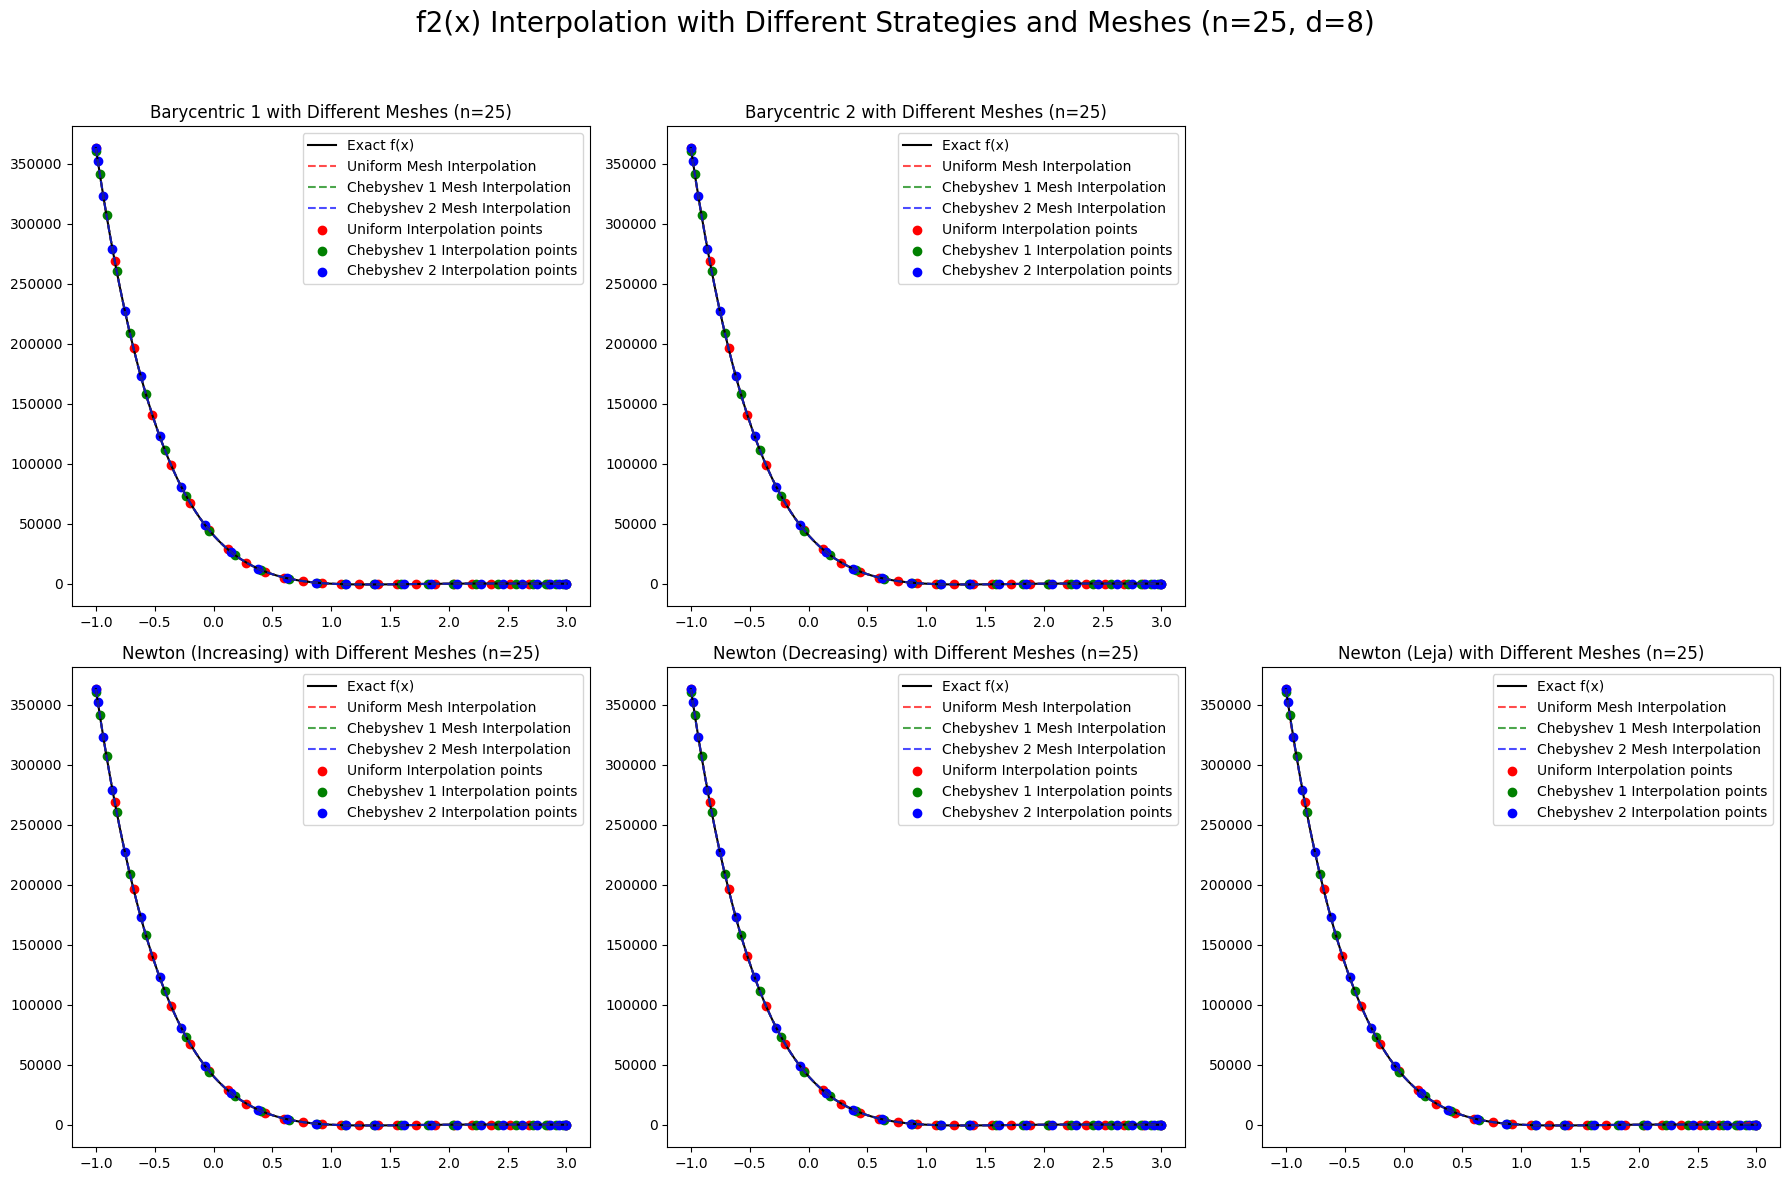

In [24]:
n = 25
degree = 8

#Barycentric 1 with different meshes

x_points = np.linspace(-1, 3, 100)

# Interpolation meshes
x_mesh_uni = create_mesh(-1, 3, n, 1) # uniform
y_mesh_uni = f2(x_mesh_uni, d=degree)
x_mesh_C1 = create_mesh(-1, 3, n, 2) # chebyshev 1
y_mesh_C1 = f2(x_mesh_C1, d=degree)
x_mesh_C2 = create_mesh(-1, 3, n, 3) # chebyshev 2
y_mesh_C2 = f2(x_mesh_C2, d=degree)

# Compute barycentric 1 weights
gamma_weights_uni, function_values = bary_1_gammas(x_mesh_uni, f2, d=degree) # uniform
gamma_weights_C1, function_values = bary_1_gammas(x_mesh_C1, f2, d=degree) # chebyshev 1
gamma_weights_C2, function_values = bary_1_gammas(x_mesh_C2, f2, d=degree) # chebyshev 2

# Evaluate interpolant
x_points = np.linspace(-1, 3, 100)
y_exact = f2(x_points, d=degree)
y_interp_uni, cond_xn1_uni, cond_xny_uni = bary_1_interpolation(x_mesh_uni, y_mesh_uni, x_points, gamma_weights_uni) # uniform
y_interp_C1, cond_xn1_C1, cond_xny_C1 = bary_1_interpolation(x_mesh_C1, y_mesh_C1, x_points, gamma_weights_C1) # chebyshev 1
y_interp_C2, cond_xn1_C2, cond_xny_C2 = bary_1_interpolation(x_mesh_C2, y_mesh_C2, x_points, gamma_weights_C2) # chebyshev 2

# Plot results

plt.figure(figsize=(18, 12))
plt.suptitle(f"f2(x) Interpolation with Different Strategies and Meshes (n={n}, d={degree})", ha='center', fontsize=20)

plt.subplot(2, 3, 1)
plt.plot(x_points, y_exact, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_uni, '--', color="red", label="Uniform Mesh Interpolation", alpha=0.7)
plt.plot(x_points, y_interp_C1, '--', color="green", label="Chebyshev 1 Mesh Interpolation", alpha=0.7)
plt.plot(x_points, y_interp_C2, '--', color="blue", label="Chebyshev 2 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_uni, y_mesh_uni, color="red", label="Uniform Interpolation points")
plt.scatter(x_mesh_C1, y_mesh_C1, color="green", label="Chebyshev 1 Interpolation points")
plt.scatter(x_mesh_C2, y_mesh_C2, color="blue", label="Chebyshev 2 Interpolation points")
plt.legend()
plt.title(f"Barycentric 1 with Different Meshes (n={n})")

# Compute maximum pointwise error for each mesh
max_error_uni = compute_max_norm(y_interp_uni, y_exact)
print("Maximum Pointwise Error (Bary 1 Uniform):", max_error_uni)
max_error_C1 = compute_max_norm(y_interp_C1, y_exact)
print("Maximum Pointwise Error (Bary 1 Chebyshev 1):", max_error_C1)
max_error_C2 = compute_max_norm(y_interp_C2, y_exact)
print("Maximum Pointwise Error (Bary 1 Chebyshev 2):", max_error_C2)


# Barycentric 2 with different meshes

# Interpolation meshes
x_mesh_uni = create_mesh(-1, 3, n, 1) # uniform
y_mesh_uni = f2(x_mesh_uni, d=degree)
x_mesh_C1 = create_mesh(-1, 3, n, 2) # chebyshev 1
y_mesh_C1 = f2(x_mesh_C1, d=degree)
x_mesh_C2 = create_mesh(-1, 3, n, 3) # chebyshev 2
y_mesh_C2 = f2(x_mesh_C2, d=degree)

# Compute barycentric 2 weights
beta_weights_uni, function_values = bary_2_betas(x_mesh_uni, 1, n, f2, d=degree) # uniform
beta_weights_C1, function_values = bary_2_betas(x_mesh_C1, 2, n, f2, d=degree) # chebyshev 1
beta_weights_C2, function_values = bary_2_betas(x_mesh_C2, 3, n, f2, d=degree) # chebyshev 2

# Evaluate interpolant
x_points = np.linspace(-1, 3, 100)
y_exact = f2(x_points, d=degree)
y_interp_uni, cond_xn1_uni, cond_xny_uni = bary_2_interpolation(x_mesh_uni, y_mesh_uni, x_points, beta_weights_uni) # uniform
y_interp_C1, cond_xn1_C1, cond_xny_C1 = bary_2_interpolation(x_mesh_C1, y_mesh_C1, x_points, beta_weights_C1) # chebyshev 1
y_interp_C2, cond_xn1_C2, cond_xny_C2 = bary_2_interpolation(x_mesh_C2, y_mesh_C2, x_points, beta_weights_C2) # chebyshev 2

# Plot results
plt.subplot(2, 3, 2)
plt.plot(x_points, y_exact, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_uni, '--', color="red", label="Uniform Mesh Interpolation", alpha=0.7)
plt.plot(x_points, y_interp_C1, '--', color="green", label="Chebyshev 1 Mesh Interpolation", alpha=0.7)
plt.plot(x_points, y_interp_C2, '--', color="blue", label="Chebyshev 2 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_uni, y_mesh_uni, color="red", label="Uniform Interpolation points")
plt.scatter(x_mesh_C1, y_mesh_C1, color="green", label="Chebyshev 1 Interpolation points")
plt.scatter(x_mesh_C2, y_mesh_C2, color="blue", label="Chebyshev 2 Interpolation points")
plt.legend()
plt.title(f"Barycentric 2 with Different Meshes (n={n})")

# Compute maximum pointwise error for each mesh
max_error_uni = compute_max_norm(y_interp_uni, y_exact)
print("Maximum Pointwise Error (Bary 2 Uniform):", max_error_uni)
max_error_C1 = compute_max_norm(y_interp_C1, y_exact)
print("Maximum Pointwise Error (Bary 2 Chebyshev 1):", max_error_C1)
max_error_C2 = compute_max_norm(y_interp_C2, y_exact)
print("Maximum Pointwise Error (Bary 2 Chebyshev 2):", max_error_C2)


# Newton increasing order with different meshes

# Interpolation meshes
x_mesh_uni = create_mesh(-1, 3, n, 1) # uniform
x_mesh_uni = mesh_order(x_mesh_uni, 1)
y_mesh_uni = f2(x_mesh_uni, d=degree)
x_mesh_C1 = create_mesh(-1, 3, n, 2) # chebyshev 1
x_mesh_C1 = mesh_order(x_mesh_C1, 1)
y_mesh_C1 = f2(x_mesh_C1, d=degree)
x_mesh_C2 = create_mesh(-1, 3, n, 3) # chebyshev 2
x_mesh_C2 = mesh_order(x_mesh_C2, 1)
y_mesh_C2 = f2(x_mesh_C2, d=degree)

# Evaluate interpolant
x_points = np.linspace(-1, 3, 100)
y_exact = f2(x_points, d=degree)
y_interp_uni = horner_interpolation(x_mesh_uni, f2, x_points, d=degree) # uniform
y_interp_C1 = horner_interpolation(x_mesh_C1, f2, x_points, d=degree) # chebyshev 1
y_interp_C2 = horner_interpolation(x_mesh_C2, f2, x_points, d=degree) # chebyshev 2

# Plot results
plt.subplot(2, 3, 4)
plt.plot(x_points, y_exact, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_uni, '--', color="red", label="Uniform Mesh Interpolation", alpha=0.7)
plt.plot(x_points, y_interp_C1, '--', color="green", label="Chebyshev 1 Mesh Interpolation", alpha=0.7)
plt.plot(x_points, y_interp_C2, '--', color="blue", label="Chebyshev 2 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_uni, y_mesh_uni, color="red", label="Uniform Interpolation points")
plt.scatter(x_mesh_C1, y_mesh_C1, color="green", label="Chebyshev 1 Interpolation points")
plt.scatter(x_mesh_C2, y_mesh_C2, color="blue", label="Chebyshev 2 Interpolation points")
plt.legend()
plt.title(f"Newton (Increasing) with Different Meshes (n={n})")

# Compute maximum pointwise error for each mesh
max_error_uni = compute_max_norm(y_interp_uni, y_exact)
print("Maximum Pointwise Error (Newton Increasing Uniform):", max_error_uni)
max_error_C1 = compute_max_norm(y_interp_C1, y_exact)
print("Maximum Pointwise Error (Newton Increasing Chebyshev 1):", max_error_C1)
max_error_C2 = compute_max_norm(y_interp_C2, y_exact)
print("Maximum Pointwise Error (Newton Increasing Chebyshev 2):", max_error_C2)


# Newton decreasing order with different meshes

# Interpolation meshes
x_mesh_uni = create_mesh(-1, 3, n, 1) # uniform
x_mesh_uni = mesh_order(x_mesh_uni, 2)
y_mesh_uni = f2(x_mesh_uni, d=degree)
x_mesh_C1 = create_mesh(-1, 3, n, 2) # chebyshev 1
x_mesh_C1 = mesh_order(x_mesh_C1, 2)
y_mesh_C1 = f2(x_mesh_C1, d=degree)
x_mesh_C2 = create_mesh(-1, 3, n, 3) # chebyshev 2
x_mesh_C2 = mesh_order(x_mesh_C2, 2)
y_mesh_C2 = f2(x_mesh_C2, d=degree)

# Evaluate interpolant
x_points = np.linspace(-1, 3, 100)
y_exact = f2(x_points, d=degree)
y_interp_uni = horner_interpolation(x_mesh_uni, f2, x_points, d=degree) # uniform
y_interp_C1 = horner_interpolation(x_mesh_C1, f2, x_points, d=degree) # chebyshev 1
y_interp_C2 = horner_interpolation(x_mesh_C2, f2, x_points, d=degree) # chebyshev 2

# Plot results
plt.subplot(2, 3, 5)
plt.plot(x_points, y_exact, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_uni, '--', color="red", label="Uniform Mesh Interpolation", alpha=0.7)
plt.plot(x_points, y_interp_C1, '--', color="green", label="Chebyshev 1 Mesh Interpolation", alpha=0.7)
plt.plot(x_points, y_interp_C2, '--', color="blue", label="Chebyshev 2 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_uni, y_mesh_uni, color="red", label="Uniform Interpolation points")
plt.scatter(x_mesh_C1, y_mesh_C1, color="green", label="Chebyshev 1 Interpolation points")
plt.scatter(x_mesh_C2, y_mesh_C2, color="blue", label="Chebyshev 2 Interpolation points")
plt.legend()
plt.title(f"Newton (Decreasing) with Different Meshes (n={n})")

# Compute maximum pointwise error for each mesh
max_error_uni = compute_max_norm(y_interp_uni, y_exact)
print("Maximum Pointwise Error (Newton Decreasing Uniform):", max_error_uni)
max_error_C1 = compute_max_norm(y_interp_C1, y_exact)
print("Maximum Pointwise Error (Newton Decreasing Chebyshev 1):", max_error_C1)
max_error_C2 = compute_max_norm(y_interp_C2, y_exact)
print("Maximum Pointwise Error (Newton Decreasing Chebyshev 2):", max_error_C2)


# Newton leja order with different meshes

# Interpolation meshes
x_mesh_uni = create_mesh(-1, 3, n, 1) # uniform
x_mesh_uni = mesh_order(x_mesh_uni, 3)
y_mesh_uni = f2(x_mesh_uni, d=degree)
x_mesh_C1 = create_mesh(-1, 3, n, 2) # chebyshev 1
x_mesh_C1 = mesh_order(x_mesh_C1, 3)
y_mesh_C1 = f2(x_mesh_C1, d=degree)
x_mesh_C2 = create_mesh(-1, 3, n, 3) # chebyshev 2
x_mesh_C2 = mesh_order(x_mesh_C2, 3)
y_mesh_C2 = f2(x_mesh_C2, d=degree)

# Evaluate interpolant
x_points = np.linspace(-1, 3, 100)
y_exact = f2(x_points, d=degree)
y_interp_uni = horner_interpolation(x_mesh_uni, f2, x_points, d=degree) # uniform
y_interp_C1 = horner_interpolation(x_mesh_C1, f2, x_points, d=degree) # chebyshev 1
y_interp_C2 = horner_interpolation(x_mesh_C2, f2, x_points, d=degree) # chebyshev 2

# Plot results
plt.subplot(2, 3, 6)
plt.plot(x_points, y_exact, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_uni, '--', color="red", label="Uniform Mesh Interpolation", alpha=0.7)
plt.plot(x_points, y_interp_C1, '--', color="green", label="Chebyshev 1 Mesh Interpolation", alpha=0.7)
plt.plot(x_points, y_interp_C2, '--', color="blue", label="Chebyshev 2 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_uni, y_mesh_uni, color="red", label="Uniform Interpolation points")
plt.scatter(x_mesh_C1, y_mesh_C1, color="green", label="Chebyshev 1 Interpolation points")
plt.scatter(x_mesh_C2, y_mesh_C2, color="blue", label="Chebyshev 2 Interpolation points")
plt.legend()
plt.title(f"Newton (Leja) with Different Meshes (n={n})")

# Compute maximum pointwise error for each mesh
max_error_uni = compute_max_norm(y_interp_uni, y_exact)
print("Maximum Pointwise Error (Newton Leja Uniform):", max_error_uni)
max_error_C1 = compute_max_norm(y_interp_C1, y_exact)
print("Maximum Pointwise Error (Newton Leja Chebyshev 1):", max_error_C1)
max_error_C2 = compute_max_norm(y_interp_C2, y_exact)
print("Maximum Pointwise Error (Newton Leja Chebyshev 2):", max_error_C2)

plt.tight_layout(rect=[0, 0, 1, 0.95])



#**f3 Testing**

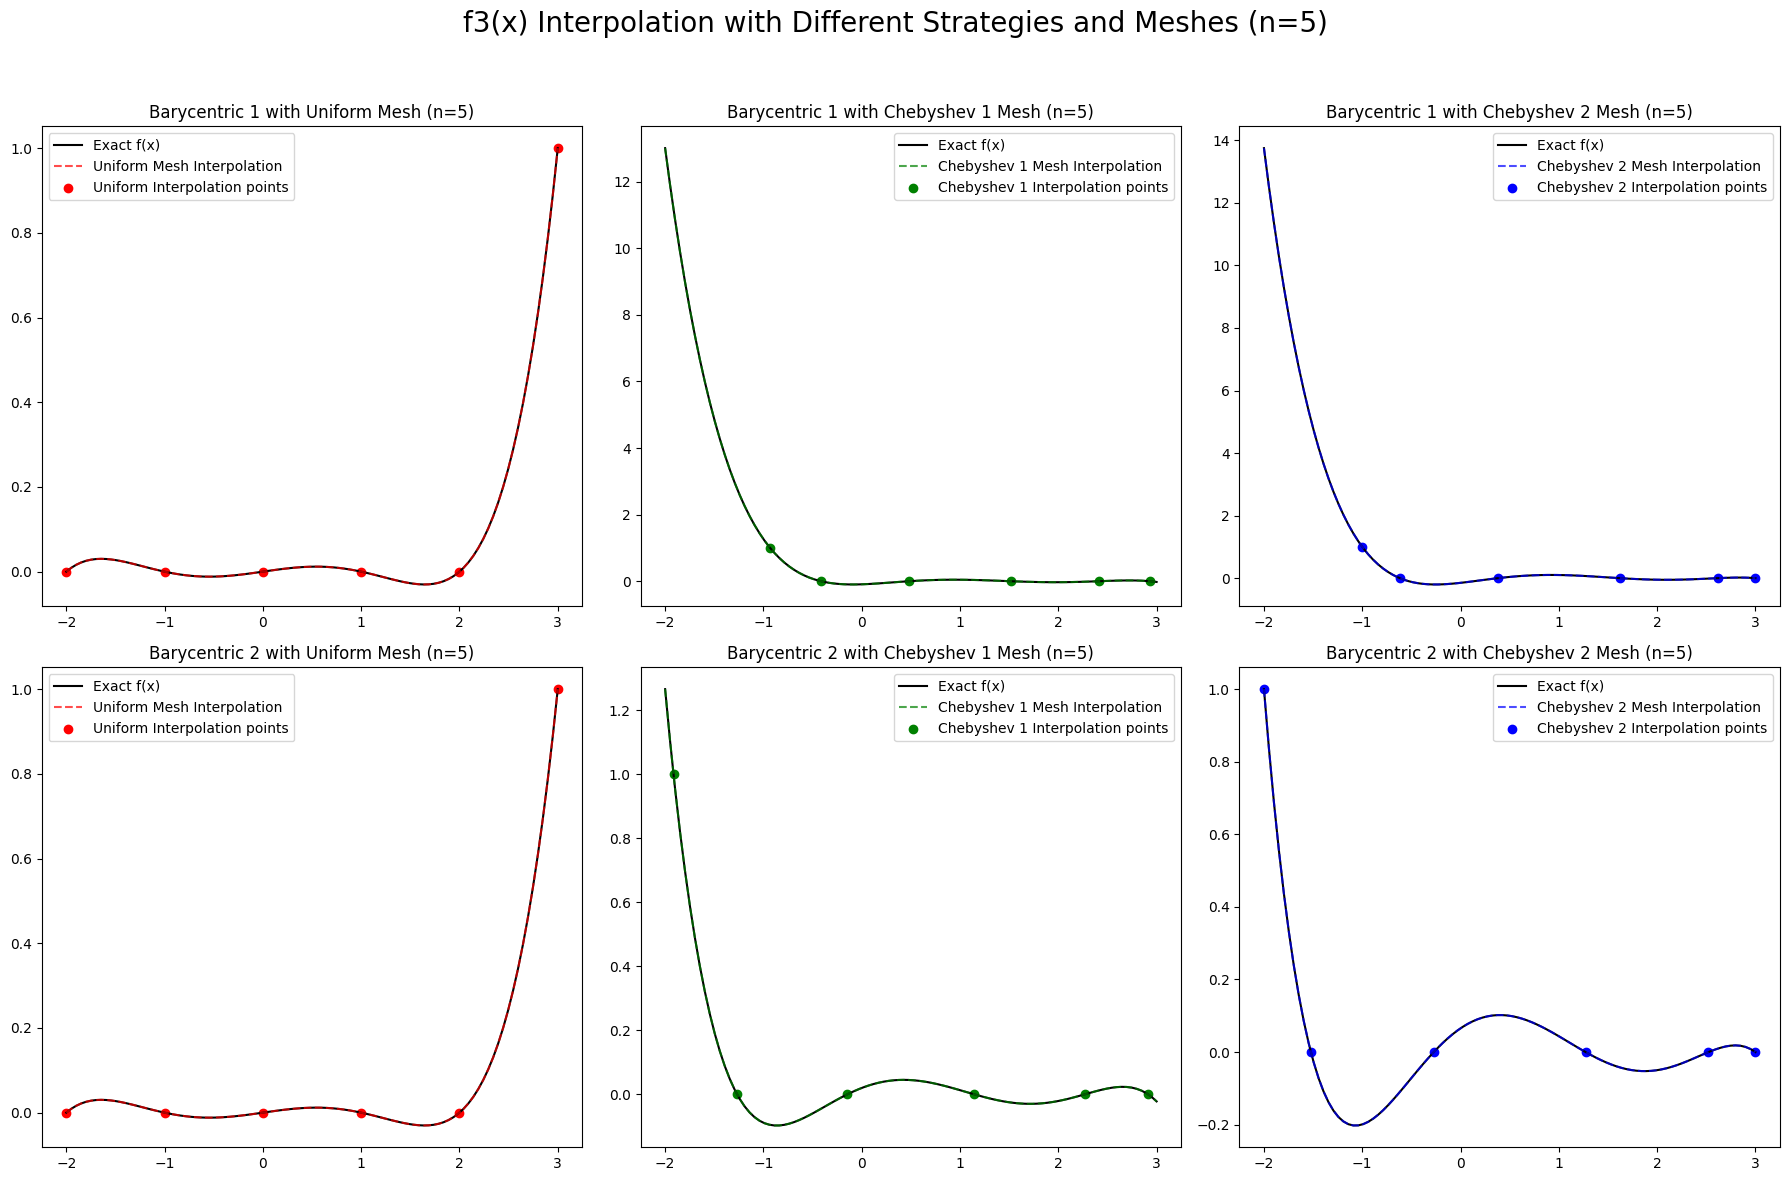

'\n# Newton leja order with different meshes\n\nx_points = np.linspace(-2, 3, 100)\n\n# Interpolation meshes\nx_mesh_uni = create_mesh(-2, 3, n, 1) # uniform\nx_mesh_uni = mesh_order(x_mesh_uni, 3)\ny_mesh_uni = f3(x_mesh_uni, x_points=x_mesh_uni)\nx_mesh_C1 = create_mesh(-2, 3, n, 2) # chebyshev 1\nx_mesh_C1 = mesh_order(x_mesh_C1, 3)\ny_mesh_C1 = f3(x_mesh_C1, x_points=x_mesh_uni)\nx_mesh_C2 = create_mesh(-2, 3, n, 3) # chebyshev 2\nx_mesh_C2 = mesh_order(x_mesh_C2, 3)\ny_mesh_C2 = f3(x_mesh_C2, x_points=x_mesh_uni)\n\n# Evaluate interpolant\nx_vals = np.linspace(-2, 3, 100)\ny_exact_uni = f3(x_mesh_uni, x_points=x_vals)\ny_exact_C1 = f3(x_mesh_C1, x_points=x_vals)\ny_exact_C2 = f3(x_mesh_C2, x_points=x_vals)\ny_interp_uni = horner_interpolation(x_mesh_uni, f3, x_vals, x_points=x_points) # uniform\ny_interp_C1 = horner_interpolation(x_mesh_C1, f3, x_vals, x_points=x_points) # chebyshev 1\ny_interp_C2 = horner_interpolation(x_mesh_C2, f3, x_vals, x_points=x_points) # chebyshev 2\n\n# 

In [25]:
n = 5

#Barycentric 1 with different meshes

x_points = np.linspace(-2, 3, 100)

# Interpolation meshes
x_mesh_uni = create_mesh(-2, 3, n, 1) # uniform
y_mesh_uni = f3(x_mesh_uni, x_points=x_mesh_uni)
x_mesh_C1 = create_mesh(-1, 3, n, 2) # chebyshev 1
y_mesh_C1 = f3(x_mesh_C1, x_points=x_mesh_C1)
x_mesh_C2 = create_mesh(-1, 3, n, 3) # chebyshev 2
y_mesh_C2 = f3(x_mesh_C2, x_points=x_mesh_C2)

# Compute barycentric 1 weights
gamma_weights_uni, function_values = bary_1_gammas(x_mesh_uni, f3, x_points=x_points) # uniform
gamma_weights_C1, function_values = bary_1_gammas(x_mesh_C1, f3, x_points=x_points) # chebyshev 1
gamma_weights_C2, function_values = bary_1_gammas(x_mesh_C2, f3, x_points=x_points) # chebyshev 2

# Evaluate interpolant
x_points = np.linspace(-2, 3, 100)
y_exact_uni = f3(x_mesh_uni, x_points=x_points)
y_exact_C1 = f3(x_mesh_C1, x_points=x_points)
y_exact_C2 = f3(x_mesh_C2, x_points=x_points)
y_interp_uni, cond_xn1_uni, cond_xny_uni = bary_1_interpolation(x_mesh_uni, y_mesh_uni, x_points, gamma_weights_uni) # uniform
y_interp_C1, cond_xn1_C1, cond_xny_C1 = bary_1_interpolation(x_mesh_C1, y_mesh_C1, x_points, gamma_weights_C1) # chebyshev 1
y_interp_C2, cond_xn1_C2, cond_xny_C2 = bary_1_interpolation(x_mesh_C2, y_mesh_C2, x_points, gamma_weights_C2) # chebyshev 2

# Plot results
plt.figure(figsize=(18, 12))
plt.suptitle(f"f3(x) Interpolation with Different Strategies and Meshes (n={n})", ha='center', fontsize=20)

plt.subplot(2, 3, 1)
plt.plot(x_points, y_exact_uni, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_uni, '--', color="red", label="Uniform Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_uni, y_mesh_uni, color="red", label="Uniform Interpolation points")
plt.legend()
plt.title(f"Barycentric 1 with Uniform Mesh (n={n})")

plt.subplot(2, 3, 2)
plt.plot(x_points, y_exact_C1, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_C1, '--', color="green", label="Chebyshev 1 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_C1, y_mesh_C1, color="green", label="Chebyshev 1 Interpolation points")
plt.legend()
plt.title(f"Barycentric 1 with Chebyshev 1 Mesh (n={n})")

plt.subplot(2, 3, 3)
plt.plot(x_points, y_exact_C2, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_C2, '--', color="blue", label="Chebyshev 2 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_C2, y_mesh_C2, color="blue", label="Chebyshev 2 Interpolation points")
plt.legend()
plt.title(f"Barycentric 1 with Chebyshev 2 Mesh (n={n})")


# Barycentric 2 with different meshes

x_points = np.linspace(-2, 3, 100)

# Interpolation meshes
x_mesh_uni = create_mesh(-2, 3, n, 1) # uniform
y_mesh_uni = f3(x_mesh_uni, x_points=x_mesh_uni)
x_mesh_C1 = create_mesh(-2, 3, n, 2) # chebyshev 1
y_mesh_C1 = f3(x_mesh_C1, x_points=x_mesh_C1)
x_mesh_C2 = create_mesh(-2, 3, n, 3) # chebyshev 2
y_mesh_C2 = f3(x_mesh_C2, x_points=x_mesh_C2)

# Compute barycentric 2 weights
beta_weights_uni, function_values = bary_2_betas(x_mesh_uni, 1, n, f3, x_points=x_points) # uniform
beta_weights_C1, function_values = bary_2_betas(x_mesh_C1, 2, n, f3, x_points=x_points) # chebyshev 1
beta_weights_C2, function_values = bary_2_betas(x_mesh_C2, 3, n, f3, x_points=x_points) # chebyshev 2

# Evaluate interpolant
x_points = np.linspace(-2, 3, 100)
y_exact_uni = f3(x_mesh_uni, x_points=x_points)
y_exact_C1 = f3(x_mesh_C1, x_points=x_points)
y_exact_C2 = f3(x_mesh_C2, x_points=x_points)
y_interp_uni, cond_xn1_uni, cond_xny_uni = bary_2_interpolation(x_mesh_uni, y_mesh_uni, x_points, beta_weights_uni) # uniform
y_interp_C1, cond_xn1_C1, cond_xny_C1 = bary_2_interpolation(x_mesh_C1, y_mesh_C1, x_points, beta_weights_C1) # chebyshev 1
y_interp_C2, cond_xn1_C2, cond_xny_C2 = bary_2_interpolation(x_mesh_C2, y_mesh_C2, x_points, beta_weights_C2) # chebyshev 2

# Plot results
plt.subplot(2, 3, 4)
plt.plot(x_points, y_exact_uni, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_uni, '--', color="red", label="Uniform Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_uni, y_mesh_uni, color="red", label="Uniform Interpolation points")
plt.legend()
plt.title(f"Barycentric 2 with Uniform Mesh (n={n})")

plt.subplot(2, 3, 5)
plt.plot(x_points, y_exact_C1, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_C1, '--', color="green", label="Chebyshev 1 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_C1, y_mesh_C1, color="green", label="Chebyshev 1 Interpolation points")
plt.legend()
plt.title(f"Barycentric 2 with Chebyshev 1 Mesh (n={n})")

plt.subplot(2, 3, 6)
plt.plot(x_points, y_exact_C2, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_C2, '--', color="blue", label="Chebyshev 2 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_C2, y_mesh_C2, color="blue", label="Chebyshev 2 Interpolation points")
plt.legend()
plt.title(f"Barycentric 2 with Chebyshev 2 Mesh (n={n})")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

'''
# Newton leja order with different meshes

x_points = np.linspace(-2, 3, 100)

# Interpolation meshes
x_mesh_uni = create_mesh(-2, 3, n, 1) # uniform
x_mesh_uni = mesh_order(x_mesh_uni, 3)
y_mesh_uni = f3(x_mesh_uni, x_points=x_mesh_uni)
x_mesh_C1 = create_mesh(-2, 3, n, 2) # chebyshev 1
x_mesh_C1 = mesh_order(x_mesh_C1, 3)
y_mesh_C1 = f3(x_mesh_C1, x_points=x_mesh_uni)
x_mesh_C2 = create_mesh(-2, 3, n, 3) # chebyshev 2
x_mesh_C2 = mesh_order(x_mesh_C2, 3)
y_mesh_C2 = f3(x_mesh_C2, x_points=x_mesh_uni)

# Evaluate interpolant
x_vals = np.linspace(-2, 3, 100)
y_exact_uni = f3(x_mesh_uni, x_points=x_vals)
y_exact_C1 = f3(x_mesh_C1, x_points=x_vals)
y_exact_C2 = f3(x_mesh_C2, x_points=x_vals)
y_interp_uni = horner_interpolation(x_mesh_uni, f3, x_vals, x_points=x_points) # uniform
y_interp_C1 = horner_interpolation(x_mesh_C1, f3, x_vals, x_points=x_points) # chebyshev 1
y_interp_C2 = horner_interpolation(x_mesh_C2, f3, x_vals, x_points=x_points) # chebyshev 2

# Plot results
plt.subplot(3, 3, 7)
plt.plot(x_points, y_exact_uni, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_uni, '--', color="red", label="Uniform Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_uni, y_mesh_uni, color="red", label="Uniform Interpolation points")
plt.legend()
plt.title(f"Newton with Uniform Leja ordered Mesh (n={n})")

plt.subplot(3, 3, 8)
plt.plot(x_points, y_exact_C1, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_C1, '--', color="green", label="Chebyshev 1 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_C1, y_mesh_C1, color="green", label="Chebyshev 1 Interpolation points")
plt.legend()
plt.title(f"Newton with Chebyshev 1 Leja ordered Mesh (n={n})")

plt.subplot(3, 3, 9)
plt.plot(x_points, y_exact_C2, color="black", label="Exact f(x)")
plt.plot(x_points, y_interp_C2, '--', color="blue", label="Chebyshev 2 Mesh Interpolation", alpha=0.7)
plt.scatter(x_mesh_C2, y_mesh_C2, color="blue", label="Chebyshev 2 Interpolation points")
plt.legend()
plt.title(f"Newton with Chebyshev 2 Leja ordered Mesh (n={n})")




# Compute maximum pointwise error for each mesh
max_error_uni = compute_max_norm(y_interp_uni, y_exact_uni)
print("Maximum Pointwise Error (Bary 1 Uniform):", max_error_uni)
max_error_C1 = compute_max_norm(y_interp_C1, y_exact_uni)
print("Maximum Pointwise Error (Bary 1 Chebyshev 1):", max_error_C1)
max_error_C2 = compute_max_norm(y_interp_C2, y_exact_uni)
print("Maximum Pointwise Error (Bary 1 Chebyshev 2):", max_error_C2)
'''


#**Runge Convergence**

Maximum Pointwise Error (Uniform mesh, n=5): 0.4303245680069646
Maximum Pointwise Error (Uniform mesh, n=10): 1.9154332794276945
Maximum Pointwise Error (Uniform mesh, n=15): 2.096726961859669
Maximum Pointwise Error (Chebyshev 1 mesh, n=5): 0.5534789101814946
Maximum Pointwise Error (Chebyshev 1 mesh, n=15): 0.08181513712164967
Maximum Pointwise Error (Chebyshev 1 mesh, n=30): 0.0020537555128662954
Maximum Pointwise Error (Chebyshev 1 mesh, n=50): 3.960486517573525e-05
Maximum Pointwise Error (Chebyshev 1 mesh, n=100): 4.873105623470764e-07
Maximum Pointwise Error (Chebyshev 1 mesh, n=250): 1.106622083857367e-06
Maximum Pointwise Error (Chebyshev 2 mesh, n=5): 0.6361717419361791
Maximum Pointwise Error (Chebyshev 2 mesh, n=15): 0.09792925283667653
Maximum Pointwise Error (Chebyshev 2 mesh, n=30): 0.0023789434338395976
Maximum Pointwise Error (Chebyshev 2 mesh, n=50): 4.419442282344033e-05
Maximum Pointwise Error (Chebyshev 2 mesh, n=100): 2.8445961863798885e-07
Maximum Pointwise Error

Text(0.5, 1.0, 'Runge Function Interpolation with Chebyshev 2 Mesh')

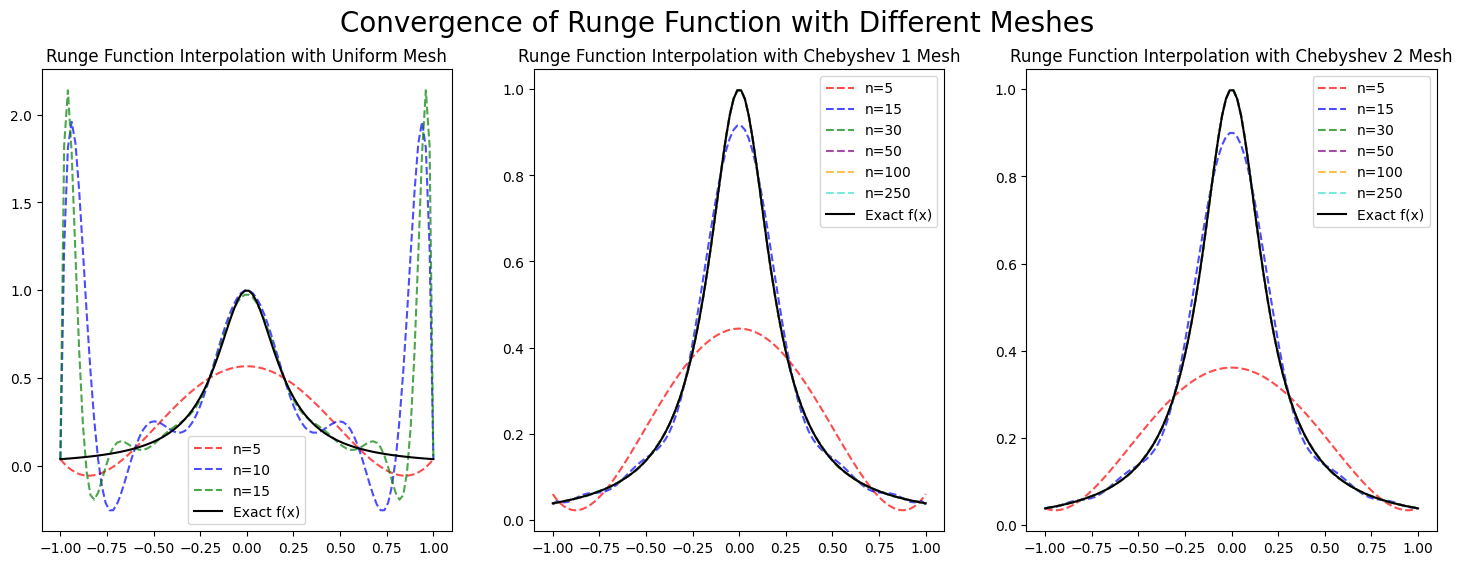

In [26]:
# Convergence of the Runge function using Barycentric 2

# Uniform

colors = ["red", "blue", "green", "purple", "orange", 'turquoise']  # Different colors for each line

plt.figure(figsize=(18, 6))
plt.suptitle("Convergence of Runge Function with Different Meshes", ha='center', fontsize=20)

plt.subplot(1,3,1)
n_list = np.array([5, 10, 15])
for i in range(len(n_list)):
    n = n_list[i]

    # Interpolation mesh
    x_mesh_uni = create_mesh(-1, 1, n, 1) # uniform
    y_mesh_uni = f4(x_mesh_uni)

    # Compute barycentric 2 weights
    beta_weights_uni, function_values = bary_2_betas(x_mesh_uni, 1, n, f4) # uniform

    # Evaluate interpolant
    x_points = np.linspace(-1, 1, 100)
    y_exact = f4(x_points)
    y_interp_uni, cond_xn1_uni, cond_xny_uni = bary_2_interpolation(x_mesh_uni, y_mesh_uni, x_points, beta_weights_uni) # uniform

    # Plot
    plt.plot(x_points, y_interp_uni, '--', color=colors[i], label=f"n={n}", alpha=0.7)

    # Compute maximum pointwise error
    max_error = compute_max_norm(y_interp_uni, y_exact)
    print(f"Maximum Pointwise Error (Uniform mesh, n={n}):", max_error)

#plt.yscale('log')
plt.plot(x_points, y_exact, color="black", label="Exact f(x)")
#plt.scatter(x_mesh_uni, y_mesh_uni, color="red", label="Uniform Interpolation points")
plt.legend()
plt.title("Runge Function Interpolation with Uniform Mesh")


# Chebyshev 1

plt.subplot(1,3,2)
n_list2 = np.array([5, 15, 30, 50, 100, 250])
for i in range(len(n_list2)):
    n = n_list2[i]

    # Interpolation mesh
    x_mesh_C1 = create_mesh(-1, 1, n, 2) # Chebyshev 1
    y_mesh_C1 = f4(x_mesh_C1)

    # Compute barycentric 2 weights
    beta_weights_C1, function_values = bary_2_betas(x_mesh_C1, 2, n, f4) # Chebyshev 1

    # Evaluate interpolant
    x_points = np.linspace(-1, 1, 100)
    y_exact = f4(x_points)
    y_interp_C1, cond_xn1_C1, cond_xny_C1 = bary_2_interpolation(x_mesh_C1, y_mesh_C1, x_points, beta_weights_C1) # Chebyshev 1

    # Plot
    plt.plot(x_points, y_interp_C1, '--', color=colors[i], label=f"n={n}", alpha=0.7)

    # Compute maximum pointwise error
    max_error = compute_max_norm(y_interp_C1, y_exact)
    print(f"Maximum Pointwise Error (Chebyshev 1 mesh, n={n}):", max_error)

#plt.yscale('log')
plt.plot(x_points, y_exact, color="black", label="Exact f(x)")
plt.legend()
plt.title("Runge Function Interpolation with Chebyshev 1 Mesh")


# Chebyshev 2

plt.subplot(1,3,3)
n_list3 = np.array([5, 15, 30, 50, 100, 250])
for i in range(len(n_list3)):
    n = n_list3[i]

    # Interpolation mesh
    x_mesh_C2 = create_mesh(-1, 1, n, 3) # Chebyshev 2
    y_mesh_C2 = f4(x_mesh_C2)

    # Compute barycentric 2 weights
    beta_weights_C2, function_values = bary_2_betas(x_mesh_C2, 3, n, f4) # Chebyshev 2

    # Evaluate interpolant
    x_points = np.linspace(-1, 1, 100)
    y_exact = f4(x_points)
    y_interp_C2, cond_xn1_C2, cond_xny_C2 = bary_2_interpolation(x_mesh_C2, y_mesh_C2, x_points, beta_weights_C2) # Chebyshev 2

    # Plot
    plt.plot(x_points, y_interp_C2, '--', color=colors[i], label=f"n={n}", alpha=0.7)

    # Compute maximum pointwise error
    max_error = compute_max_norm(y_interp_C2, y_exact)
    print(f"Maximum Pointwise Error (Chebyshev 2 mesh, n={n}):", max_error)

#plt.yscale('log')
plt.plot(x_points, y_exact, color="black", label="Exact f(x)")
plt.legend()
plt.title("Runge Function Interpolation with Chebyshev 2 Mesh")







#**Conditioning**

<ipython-input-27-1449286d1d49>:25: RuntimeWarning: invalid value encountered in divide
  cond_xny = cond_xny_numer / np.abs(y_interp)


Barycentric 1 Mean K(x,n,y) for n=5:  nan
Barycentric 1 Lebesgue Constant for n=5:  1.9876970291437397
Barycentric 1 Mean K(x,n,y) for n=10:  nan
Barycentric 1 Lebesgue Constant for n=10:  2.419553248205326
Barycentric 1 Mean K(x,n,y) for n=20:  nan
Barycentric 1 Lebesgue Constant for n=20:  2.8515639224211675
Barycentric 1 Mean K(x,n,y) for n=30:  nan
Barycentric 1 Lebesgue Constant for n=30:  3.123911219108694
Barycentric 2 Mean K(x,n,y) for n=5:  16.003829716738085
Barycentric 2 Mean K(x,n,y) for n=10:  2.252752065267162
Barycentric 2 Mean K(x,n,y) for n=20:  5.908883624054738
Barycentric 2 Mean K(x,n,y) for n=30:  8.560175129896018


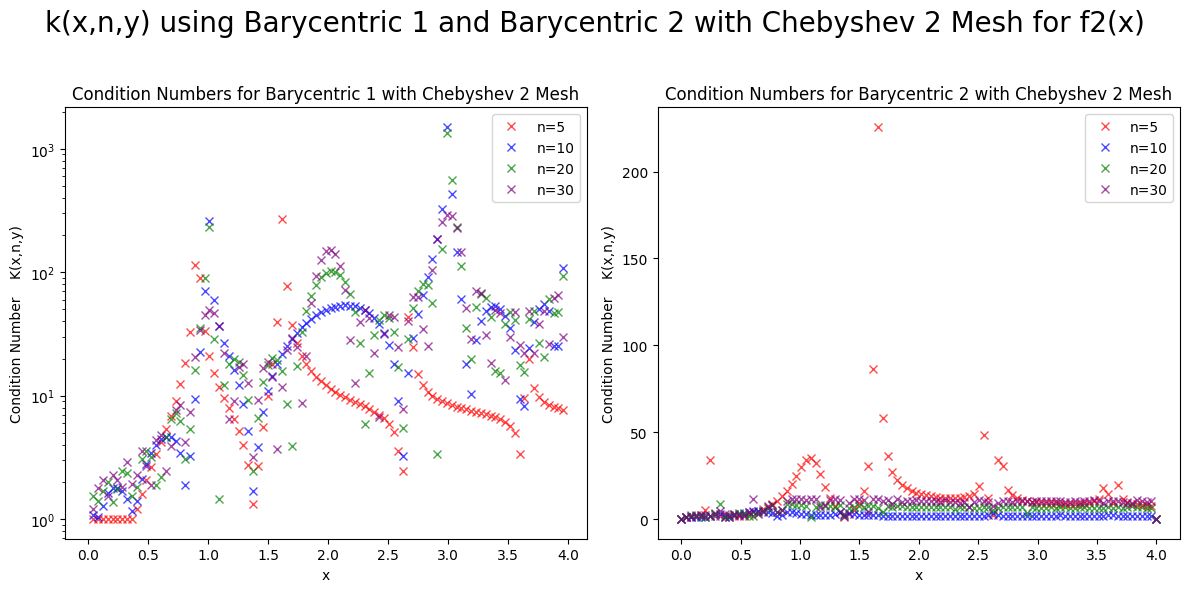

In [27]:
degree = 8
n_list = np.array([5, 10, 20, 30])
colors = ["red", "blue", "green", "purple"]  # Different colors for each line

#epsilon = 1e-8  # Threshold to prevent division by very small y_interp

# Barycentric 1 Condition Numbers

plt.figure(figsize=(12, 6))
plt.suptitle("k(x,n,y) using Barycentric 1 and Barycentric 2 with Chebyshev 2 Mesh for f2(x)", ha='center', fontsize=20)

plt.subplot(1,2,1)
for i in range(len(n_list)):
    x_points = np.linspace(0, 4, 100)
    y_exact = f2(x_points, d=degree)

    x_mesh = create_mesh(0, 4, n_list[i], 3)
    y_mesh_double = np.array([f2(x, d=degree) for x in x_mesh], dtype=np.float64)
    gamma_weights, function_values = bary_1_gammas(x_mesh, f2, dtype=np.float64, d=degree)
    y_interp, cond_xn1, cond_xny_numer = bary_1_interpolation(x_mesh, y_mesh_double, x_points, gamma_weights, dtype=np.float64)

    # Prevent division by near-zero values
    #print(y_interp)
    #cond_xny = cond_xny_numer / np.maximum(np.abs(y_interp), epsilon)
    cond_xny = cond_xny_numer / np.abs(y_interp)
    print(f"Barycentric 1 Mean K(x,n,y) for n={n_list[i]}: ", np.mean(cond_xny))

    plt.plot(x_points, cond_xny, 'x', color=colors[i], label=f"n={n_list[i]}", alpha=0.7)

    print(f"Barycentric 1 Lebesgue Constant for n={n_list[i]}: ", np.max(cond_xn1))

plt.yscale('log')
plt.legend()
plt.title("Condition Numbers for Barycentric 1 with Chebyshev 2 Mesh")
plt.xlabel("x")
plt.ylabel("Condition Number    K(x,n,y)")


# Barycentric 2 Condition Numbers

plt.subplot(1,2,2)
for i in range(len(n_list)):
    x_points = np.linspace(0, 4, 100)
    y_exact = f2(x_points, d=degree)

    x_mesh = create_mesh(0, 4, n_list[i], 3)
    y_mesh_double = np.array([f2(x, d=degree) for x in x_mesh], dtype=np.float64)
    beta_weights, function_values = bary_2_betas(x_mesh, 3, n_list[i], f2, dtype=np.float64, d=degree)
    y_interp, cond_xn1, cond_xny = bary_2_interpolation(x_mesh, y_mesh_double, x_points, beta_weights, dtype=np.float64)

    print(f"Barycentric 2 Mean K(x,n,y) for n={n_list[i]}: ", np.mean(cond_xny))

    plt.plot(x_points, cond_xny, 'x', color=colors[i], label=f"n={n_list[i]}", alpha=0.7)

    #print(f"Lebesgue Constant for n={n_list[i]}: ", np.max(cond_xn1))

#plt.yscale('log')
plt.legend()
plt.title("Condition Numbers for Barycentric 2 with Chebyshev 2 Mesh")
plt.xlabel("x")
plt.ylabel("Condition Number    K(x,n,y)")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


#**Relative Error / Stability**

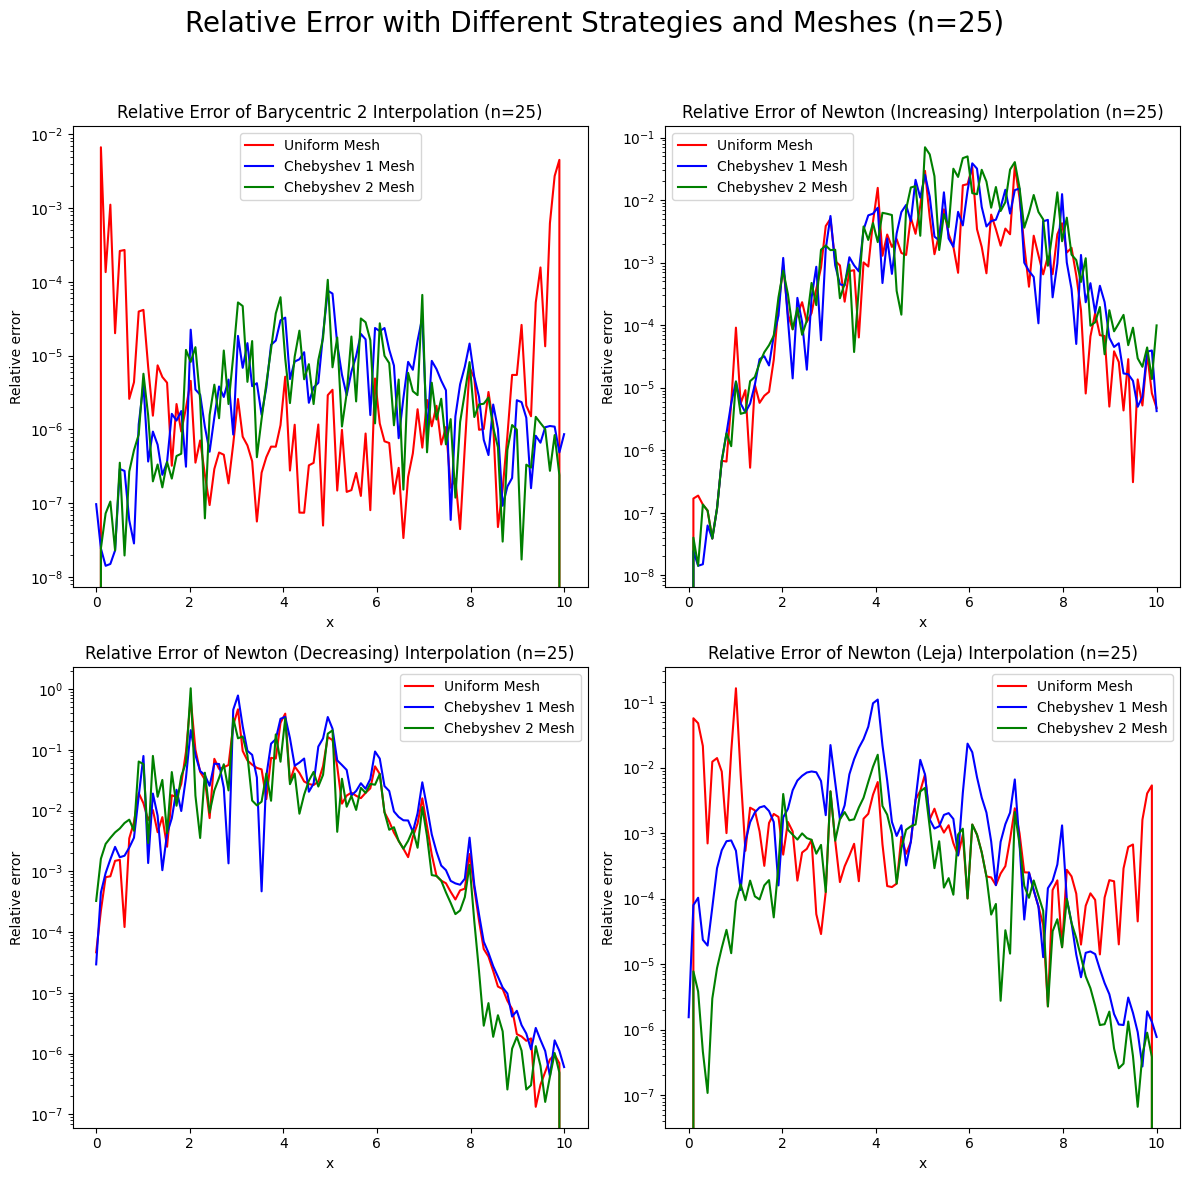

In [28]:
n = 25
degree = 8

mesh_types = np.array([1, 2, 3])
mesh_labels = {1: "Uniform Mesh", 2: "Chebyshev 1 Mesh", 3: "Chebyshev 2 Mesh"}
colors = ["red", "blue", "green", "purple"]

plt.figure(figsize=(12, 12))
plt.suptitle(f"Relative Error with Different Strategies and Meshes (n={n})", ha='center', fontsize=20)

# Barycentric 2
plt.subplot(2, 2, 1)
for i in range(len(mesh_types)):
    x_mesh = create_mesh(0, 10, n, mesh_types[i])
    x_points = np.linspace(0, 10, 100)

    # Double Precision
    y_mesh_double = np.array([f2(x, d=degree) for x in x_mesh], dtype=np.float64)
    beta_weights_double, _ = bary_2_betas(x_mesh, mesh_types[i], n, f2, dtype=np.float64, d=degree)
    pn_double, _, cond_xny = bary_2_interpolation(x_mesh, y_mesh_double, x_points, beta_weights_double, dtype=np.float64)

    # Single Precision
    y_mesh_single = np.array([f2(x, d=degree) for x in x_mesh], dtype=np.float32)
    beta_weights_single, _ = bary_2_betas(x_mesh, mesh_types[i], n, f2, dtype=np.float32, d=degree)
    pn_single, _, _ = bary_2_interpolation(x_mesh, y_mesh_single, x_points, beta_weights_single, dtype=np.float32)

    # Calculate relative error
    rel_err = relative_error(pn_double, pn_single)
    plt.plot(x_points, rel_err, color=colors[i], label=mesh_labels[mesh_types[i]])

plt.yscale('log')
plt.legend()
plt.xlabel("x")
plt.ylabel("Relative error")
plt.title(f"Relative Error of Barycentric 2 Interpolation (n={n})")

# Newton Increasing
plt.subplot(2, 2, 2)
for i in range(len(mesh_types)):
    x_mesh = create_mesh(0, 10, n, mesh_types[i])
    x_mesh = mesh_order(x_mesh, 1)
    x_points = np.linspace(0, 10, 100)

    # Double Precision
    y_mesh_double = np.array([f2(x, d=degree) for x in x_mesh], dtype=np.float64)
    pn_double = horner_interpolation(x_mesh, f2, x_points, dtype=np.float64, d=degree)

    # Single Precision
    y_mesh_single = np.array([f2(x, d=degree) for x in x_mesh], dtype=np.float32)
    pn_single = horner_interpolation(x_mesh, f2, x_points, dtype=np.float32, d=degree)

    # Calculate relative error
    rel_err = relative_error(pn_double, pn_single)
    plt.plot(x_points, rel_err, color=colors[i], label=mesh_labels[mesh_types[i]])

plt.yscale('log')
plt.legend()
plt.xlabel("x")
plt.ylabel("Relative error")
plt.title(f"Relative Error of Newton (Increasing) Interpolation (n={n})")

# Newton Decreasing
plt.subplot(2, 2, 3)
for i in range(len(mesh_types)):
    x_mesh = create_mesh(0, 10, n, mesh_types[i])
    x_mesh = mesh_order(x_mesh, 2)
    x_points = np.linspace(0, 10, 100)

    # Double Precision
    y_mesh_double = np.array([f2(x, d=degree) for x in x_mesh], dtype=np.float64)
    pn_double = horner_interpolation(x_mesh, f2, x_points, dtype=np.float64, d=degree)

    # Single Precision
    y_mesh_single = np.array([f2(x, d=degree) for x in x_mesh], dtype=np.float32)
    pn_single = horner_interpolation(x_mesh, f2, x_points, dtype=np.float32, d=degree)

    # Calculate relative error
    rel_err = relative_error(pn_double, pn_single)
    plt.plot(x_points, rel_err, color=colors[i], label=mesh_labels[mesh_types[i]])

plt.yscale('log')
plt.legend()
plt.xlabel("x")
plt.ylabel("Relative error")
plt.title(f"Relative Error of Newton (Decreasing) Interpolation (n={n})")

# Newton Leja
plt.subplot(2, 2, 4)
for i in range(len(mesh_types)):
    x_mesh = create_mesh(0, 10, n, mesh_types[i])
    x_mesh = mesh_order(x_mesh, 3)
    x_points = np.linspace(0, 10, 100)

    # Double Precision
    y_mesh_double = np.array([f2(x, d=degree) for x in x_mesh], dtype=np.float64)
    pn_double = horner_interpolation(x_mesh, f2, x_points, dtype=np.float64, d=degree)

    # Single Precision
    y_mesh_single = np.array([f2(x, d=degree) for x in x_mesh], dtype=np.float32)
    pn_single = horner_interpolation(x_mesh, f2, x_points, dtype=np.float32, d=degree)

    # Calculate relative error
    rel_err = relative_error(pn_double, pn_single)
    plt.plot(x_points, rel_err, color=colors[i], label=mesh_labels[mesh_types[i]])

plt.yscale('log')
plt.legend()
plt.xlabel("x")
plt.ylabel("Relative error")
plt.title(f"Relative Error of Newton (Leja) Interpolation (n={n})")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
